# Task 2.2 — Reproduction of the Core Contribution
**Paper**: *Efficient Online Learning for Large-Scale Sparse Kernel Logistic Regression* (AAAI 2012)

## Contribution Being Reproduced and Evaluation Metric

**Contribution**: I am reproducing the Auxiliary-function-based conservative online KLR algorithm (Algorithm 3) — the paper's main contribution — which produces sparse kernel classifiers by stochastically skipping gradient updates on confidently classified examples.

**Evaluation metric**: Classification accuracy (fraction of correctly classified test examples) and sparsity (fraction of training examples NOT used as support vectors), consistent with Tables 1–2 and Figures 1–4 of the paper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.model_selection import KFold

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

X_train = np.load('data/X_train.npy')
X_test  = np.load('data/X_test.npy')
y_train = np.load('data/y_train.npy')
y_test  = np.load('data/y_test.npy')
sigma   = np.load('data/sigma.npy')[0]

print(f'Training: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples')
print(f'Kernel width sigma = {sigma:.4f}')

Training: 455 samples, Test: 114 samples
Kernel width sigma = 2.9823


## Gaussian Kernel Function

The paper uses the Gaussian kernel $\kappa(x_i, x_j) = \exp\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right)$. The kernel width $\sigma$ is set to the 5th percentile of pairwise distances (Section "Experiments on medium-size data sets"). We verify that $\kappa(x,x) = 1 \le 1$ as assumed throughout the paper.

In [2]:
def gaussian_kernel_matrix(X1, X2, sigma):
    sq_dists = cdist(X1, X2, 'sqeuclidean')
    return np.exp(-sq_dists / (2.0 * sigma ** 2))

def gaussian_kernel_vector(x, X, sigma):
    sq_dists = np.sum((X - x) ** 2, axis=1)
    return np.exp(-sq_dists / (2.0 * sigma ** 2))

print('kappa(x, x) =', np.exp(0), '(always 1 for Gaussian kernel, satisfying the assumption)')

kappa(x, x) = 1.0 (always 1 for Gaussian kernel, satisfying the assumption)


This block defines the Gaussian kernel computation used throughout the algorithms. The function `gaussian_kernel_matrix` computes the full $n \times m$ kernel matrix between two sets of points, while `gaussian_kernel_vector` is the single-point variant needed in the online update. *Reference: Section "Experiments" and the kernel assumption $\kappa(x,x) \le 1$.*

These kernel utility functions are defined in each notebook to ensure self-contained reproducibility without external module dependencies.

## Algorithm 1: Non-Conservative Online Learning (NC)

This is the baseline online learning algorithm. It processes each training example and always performs a gradient update using the logit loss gradient $\ell'(z) = p(y|f(x)) - 1$ (Eq. 4), adding every example as a support vector.

In [3]:
def nc_online_klr(X_train, y_train, X_test, y_test, sigma, eta, R):
    """
    Algorithm 1 -- Non-Conservative online learning for KLR.
    Returns: test accuracy, # SVs, acc_history, sv_history.
    """
    T = len(X_train)
    sv_list, alpha_list = [], []
    acc_history, n_sv_history = [], []
    cumulative_test_pred = np.zeros(len(X_test))
    for t in range(T):
        xt, yt = X_train[t], y_train[t]
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            ft_xt = np.dot(alpha_arr, gaussian_kernel_vector(xt, sv_arr, sigma))
        else:
            ft_xt = 0.0
        p_yt = 1.0 / (1.0 + np.exp(-yt * ft_xt))
        grad = p_yt - 1.0
        alpha_new = -eta * yt * grad
        sv_list.append(xt.copy())
        alpha_list.append(alpha_new)
        sv_arr = np.array(sv_list)
        alpha_arr = np.array(alpha_list)
        K_sv = gaussian_kernel_matrix(sv_arr, sv_arr, sigma)
        norm_sq = alpha_arr @ K_sv @ alpha_arr
        norm_f = np.sqrt(max(norm_sq, 0))
        if norm_f > R:
            scale = R / norm_f
            alpha_list = [a * scale for a in alpha_list]
            alpha_arr = np.array(alpha_list)
        K_test = gaussian_kernel_matrix(sv_arr, X_test, sigma)
        f_test = alpha_arr @ K_test
        cumulative_test_pred += f_test
        avg_pred = cumulative_test_pred / (t + 1)
        y_pred = np.sign(avg_pred)
        y_pred[y_pred == 0] = 1
        acc = np.mean(y_pred == y_test)
        acc_history.append(acc)
        n_sv_history.append(len(sv_list))
    return acc_history[-1], len(sv_list), acc_history, n_sv_history

print('NC algorithm defined.')

NC algorithm defined.


This function implements Algorithm 1 from the paper. For each training example:
- It computes $f_t(x_t) = \sum_i \alpha_i \kappa(x_i, x_t)$ (the current classifier's prediction).
- It computes the gradient $\ell'(y_t f_t(x_t)) = p(y_t|f_t(x_t)) - 1$ (Eq. 4).
- It adds a new support vector with weight $-\eta \cdot y_t \cdot \ell'$ (Eq. 3, Algorithm 1 line 6).
- It projects onto $\Omega$ by rescaling all weights if $\|f\|_{\mathcal{H}} > R$ (Algorithm 1 line 7).

## Algorithm 2: Classification-Margin-Based Conservative (Margin)

This introduces the Bernoulli gating with sampling probability from Eq. (5).

In [4]:
def margin_online_klr(X_train, y_train, X_test, y_test, sigma, eta, R):
    """
    Algorithm 2 -- Margin-based conservative online KLR.
    Sampling probability: p_t = (2-eta)/(2-eta + eta*p(y_t|f_t(x_t)))  [Eq. 5]
    """
    T = len(X_train)
    sv_list, alpha_list = [], []
    acc_history, n_sv_history = [], []
    cumulative_test_pred = np.zeros(len(X_test))
    num_updates = 0
    for t in range(T):
        xt, yt = X_train[t], y_train[t]
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            ft_xt = np.dot(alpha_arr, gaussian_kernel_vector(xt, sv_arr, sigma))
        else:
            ft_xt = 0.0
        p_yt = 1.0 / (1.0 + np.exp(-yt * ft_xt))
        pt = (2.0 - eta) / (2.0 - eta + eta * p_yt)
        Zt = np.random.binomial(1, min(pt, 1.0))
        if Zt == 1:
            grad = p_yt - 1.0
            alpha_new = -eta * yt * grad
            sv_list.append(xt.copy())
            alpha_list.append(alpha_new)
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            K_sv = gaussian_kernel_matrix(sv_arr, sv_arr, sigma)
            norm_sq = alpha_arr @ K_sv @ alpha_arr
            norm_f = np.sqrt(max(norm_sq, 0))
            if norm_f > R:
                scale = R / norm_f
                alpha_list = [a * scale for a in alpha_list]
            num_updates += 1
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            K_test = gaussian_kernel_matrix(sv_arr, X_test, sigma)
            f_test = alpha_arr @ K_test
        else:
            f_test = np.zeros(len(X_test))
        cumulative_test_pred += f_test
        avg_pred = cumulative_test_pred / (t + 1)
        y_pred = np.sign(avg_pred)
        y_pred[y_pred == 0] = 1
        acc = np.mean(y_pred == y_test)
        acc_history.append(acc)
        n_sv_history.append(num_updates)
    return acc_history[-1], num_updates, acc_history, n_sv_history

print('Margin algorithm defined.')

Margin algorithm defined.


This implements Algorithm 2. The only difference from NC is the Bernoulli gate before the update:
- $p_t = (2 - \eta) / (2 - \eta + \eta \cdot p(y_t|f_t(x_t)))$ (Eq. 5) — correctly classified examples with high posterior probability get a lower $p_t$, so they are more likely to be skipped.
- $Z_t \sim \text{Bernoulli}(p_t)$: only when $Z_t = 1$ does the update happen.

## Algorithm 3: Auxiliary-Function-Based Conservative (Auxiliary) — Main Contribution

This is the core contribution of the paper. It uses $h(z) = \ln(\gamma + e^{-z})$ as the auxiliary function, with $\gamma \ge 1$ controlling sparsity.

In [5]:
def auxiliary_online_klr(X_train, y_train, X_test, y_test, sigma, eta, R, gamma):
    """
    Algorithm 3 -- Auxiliary function based conservative online KLR.
    h(z) = ln(gamma + exp(-z)), p_t = l/h (Eq. 6). Returns history for plotting.
    """
    T = len(X_train)
    sv_list, alpha_list = [], []
    acc_history, n_sv_history = [], []
    cumulative_test_pred = np.zeros(len(X_test))
    num_updates = 0
    for t in range(T):
        xt, yt = X_train[t], y_train[t]
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            ft_xt = np.dot(alpha_arr, gaussian_kernel_vector(xt, sv_arr, sigma))
        else:
            ft_xt = 0.0
        margin = yt * ft_xt
        loss_val = np.log(1.0 + np.exp(-margin))
        h_val = np.log(gamma + np.exp(-margin))
        pt = loss_val / h_val if h_val > 1e-12 else 1.0
        pt = min(max(pt, 0.0), 1.0)
        Zt = np.random.binomial(1, pt)
        if Zt == 1:
            exp_neg_margin = np.exp(-margin)
            h_grad = -exp_neg_margin / (gamma + exp_neg_margin)
            alpha_new = -eta * yt * h_grad
            sv_list.append(xt.copy())
            alpha_list.append(alpha_new)
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            K_sv = gaussian_kernel_matrix(sv_arr, sv_arr, sigma)
            norm_sq = alpha_arr @ K_sv @ alpha_arr
            norm_f = np.sqrt(max(norm_sq, 0))
            if norm_f > R:
                scale = R / norm_f
                alpha_list = [a * scale for a in alpha_list]
            num_updates += 1
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            K_test = gaussian_kernel_matrix(sv_arr, X_test, sigma)
            f_test = alpha_arr @ K_test
        else:
            f_test = np.zeros(len(X_test))
        cumulative_test_pred += f_test
        avg_pred = cumulative_test_pred / (t + 1)
        y_pred = np.sign(avg_pred)
        y_pred[y_pred == 0] = 1
        acc = np.mean(y_pred == y_test)
        acc_history.append(acc)
        n_sv_history.append(num_updates)
    return acc_history[-1], num_updates, acc_history, n_sv_history

print('Auxiliary algorithm defined.')

Auxiliary algorithm defined.


This is the key algorithm of the paper (Algorithm 3). Two things differ from NC:

1. **Sampling probability** $p_t = \ell(y_t f_t(x_t)) / h(y_t f_t(x_t))$ (Eq. 6). Since $h(z) = \ln(\gamma + e^{-z}) \ge \ell(z) = \ln(1 + e^{-z})$ when $\gamma \ge 1$, we have $p_t \le 1$. Larger $\gamma$ means smaller $p_t$ for correctly classified points, producing sparser classifiers.

2. **Gradient of $h$, not $\ell$**: When updating, the algorithm uses $h'(y_t f_t(x_t))$ instead of $\ell'(y_t f_t(x_t))$. For our auxiliary function, $h'(z) = -e^{-z}/(\gamma + e^{-z})$. This ensures the expected update matches the requirement for Theorem 4.

## Hyperparameter Selection via 5-Fold Cross-Validation

Following the paper, $R$ is chosen from a candidate set. The paper uses 5-fold CV on the training set (Section "Experiments on medium-size data sets"). We do the same here: for each $R$ candidate, we run the NC algorithm on 4 folds and evaluate on the held-out fold, averaging across folds. This avoids information leakage from the test set.

- $R$ candidates: $\{1, 5, 10, 20\}$ (constrained so $\eta = R/\sqrt{T} < 2$ for Margin)
- $\eta = R / \sqrt{T}$ (theoretically recommended step size from Theorem 1)
- $\gamma \in \{1, 2, 5, 10, 50, 101\}$ for the Auxiliary algorithm

In [6]:
def nc_online_klr_cv(X_tr, y_tr, X_val, y_val, sigma, eta, R):
    """NC for CV -- returns only accuracy (lightweight)."""
    T = len(X_tr)
    sv_list, alpha_list = [], []
    cumulative_val_pred = np.zeros(len(X_val))
    for t in range(T):
        xt, yt = X_tr[t], y_tr[t]
        if len(sv_list) > 0:
            sv_arr = np.array(sv_list)
            alpha_arr = np.array(alpha_list)
            ft_xt = np.dot(alpha_arr, gaussian_kernel_vector(xt, sv_arr, sigma))
        else:
            ft_xt = 0.0
        p_yt = 1.0 / (1.0 + np.exp(-yt * ft_xt))
        grad = p_yt - 1.0
        alpha_new = -eta * yt * grad
        sv_list.append(xt.copy())
        alpha_list.append(alpha_new)
        sv_arr = np.array(sv_list)
        alpha_arr = np.array(alpha_list)
        K_sv = gaussian_kernel_matrix(sv_arr, sv_arr, sigma)
        norm_sq = alpha_arr @ K_sv @ alpha_arr
        norm_f = np.sqrt(max(norm_sq, 0))
        if norm_f > R:
            alpha_list = [a * R / norm_f for a in alpha_list]
            alpha_arr = np.array(alpha_list)
        K_val = gaussian_kernel_matrix(sv_arr, X_val, sigma)
        f_val = alpha_arr @ K_val
        cumulative_val_pred += f_val
    avg_pred = cumulative_val_pred / T
    y_pred = np.sign(avg_pred)
    y_pred[y_pred == 0] = 1
    return np.mean(y_pred == y_val)

print('CV helper defined.')

T = len(X_train)
R_candidates = [1, 5, 10, 20]
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print('Finding best R via 5-fold CV on training set only...')
best_R = None
best_cv_acc = 0
for R_cand in R_candidates:
    fold_accs = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_tr_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
        eta_fold = R_cand / np.sqrt(len(X_tr_fold))
        np.random.seed(RANDOM_SEED)
        fold_acc = nc_online_klr_cv(X_tr_fold, y_tr_fold, X_val_fold, y_val_fold, sigma, eta_fold, R_cand)
        fold_accs.append(fold_acc)
    mean_acc = np.mean(fold_accs)
    print(f'  R={R_cand:>5}, mean 5-fold CV accuracy = {mean_acc:.4f}')
    if mean_acc > best_cv_acc:
        best_cv_acc = mean_acc
        best_R = R_cand

print(f'\nBest R = {best_R} (CV accuracy = {best_cv_acc:.4f})')
eta_best = best_R / np.sqrt(T)
print(f'Using eta = R/sqrt(T) = {eta_best:.4f}')
print(f'eta < 2 check for Margin algorithm: {eta_best < 2}')

np.save('data/best_R.npy', np.array([best_R]))
print(f'Saved best_R={best_R} to data/best_R.npy for downstream notebooks.')

CV helper defined.
Finding best R via 5-fold CV on training set only...


  R=    1, mean 5-fold CV accuracy = 0.9099


  R=    5, mean 5-fold CV accuracy = 0.9385


  R=   10, mean 5-fold CV accuracy = 0.9495


  R=   20, mean 5-fold CV accuracy = 0.9604

Best R = 20 (CV accuracy = 0.9604)
Using eta = R/sqrt(T) = 0.9376
eta < 2 check for Margin algorithm: True
Saved best_R=20 to data/best_R.npy for downstream notebooks.


This cell selects the best $R$ using proper 5-fold cross-validation on the training set, avoiding information leakage from the test set. The paper searches $R \in \{1, 10, \ldots, 10^5\}$ via 5-fold CV; we follow the same methodology with a smaller candidate set appropriate for our dataset size. $\eta = R/\sqrt{T}$ follows the theoretical recommendation from Theorem 1.

In [7]:
print('Running all three algorithms with best R on the test set...')
print(f'R = {best_R}, eta = {eta_best:.4f}, sigma = {sigma:.4f}\n')

np.random.seed(RANDOM_SEED)
nc_acc, nc_sv, nc_acc_hist, nc_sv_hist = nc_online_klr(
    X_train, y_train, X_test, y_test, sigma, eta_best, best_R
)
print(f'NC       -- Accuracy: {nc_acc:.4f}, Support Vectors: {nc_sv}')

np.random.seed(RANDOM_SEED)
margin_acc, margin_sv, margin_acc_hist, margin_sv_hist = margin_online_klr(
    X_train, y_train, X_test, y_test, sigma, eta_best, best_R
)
print(f'Margin   -- Accuracy: {margin_acc:.4f}, Support Vectors: {margin_sv}')

gammas = [1, 2, 5, 10, 50, 101]
aux_results = {}
for g in gammas:
    np.random.seed(RANDOM_SEED)
    a_acc, a_sv, a_acc_hist, a_sv_hist = auxiliary_online_klr(
        X_train, y_train, X_test, y_test, sigma, eta_best, best_R, g
    )
    aux_results[g] = (a_acc, a_sv, a_acc_hist, a_sv_hist)
    print(f'Aux(g={g:>3}) -- Accuracy: {a_acc:.4f}, Support Vectors: {a_sv}')

Running all three algorithms with best R on the test set...
R = 20, eta = 0.9376, sigma = 2.9823



NC       -- Accuracy: 0.9649, Support Vectors: 455
Margin   -- Accuracy: 0.9649, Support Vectors: 266


Aux(g=  1) -- Accuracy: 0.9649, Support Vectors: 455
Aux(g=  2) -- Accuracy: 0.9561, Support Vectors: 171
Aux(g=  5) -- Accuracy: 0.9474, Support Vectors: 134


Aux(g= 10) -- Accuracy: 0.9386, Support Vectors: 107
Aux(g= 50) -- Accuracy: 0.8772, Support Vectors: 76
Aux(g=101) -- Accuracy: 0.8772, Support Vectors: 67


This cell runs all three algorithms with the CV-selected $R$: NC (dense baseline), Margin (conservative with sampling probability from Eq. 5), and Auxiliary with several $\gamma$ values. This mirrors the experimental setup in Figures 1-3 of the paper.

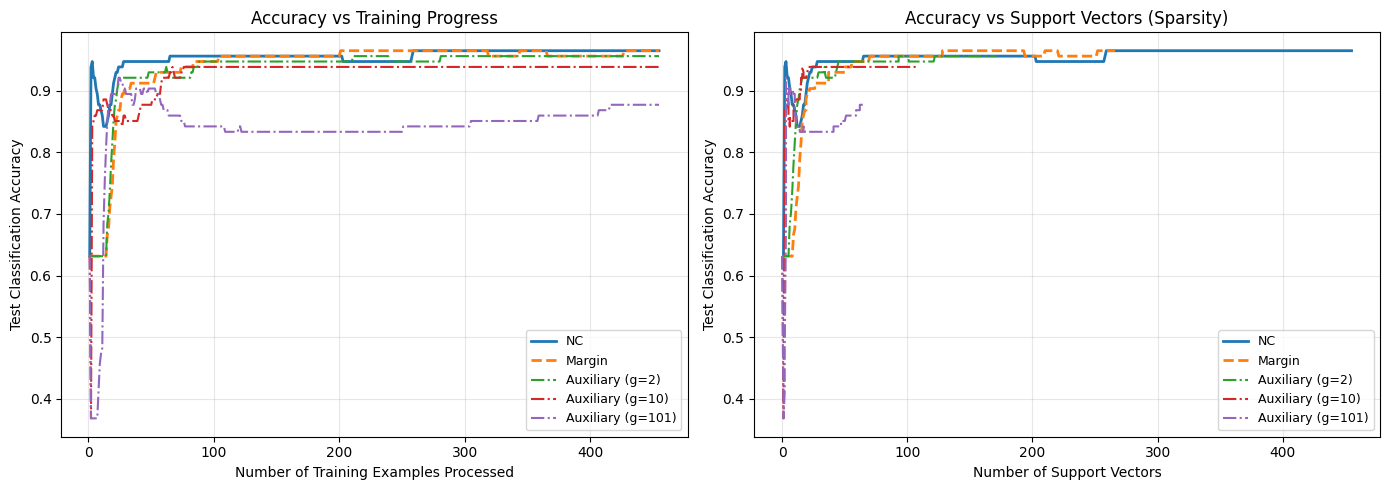

Saved: results/reproduction_accuracy_vs_sv.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, T+1), nc_acc_hist, label='NC', linewidth=2)
axes[0].plot(range(1, T+1), margin_acc_hist, label='Margin', linewidth=2, linestyle='--')
for g in [2, 10, 101]:
    axes[0].plot(range(1, T+1), aux_results[g][2],
                label=f'Auxiliary (g={g})', linewidth=1.5, linestyle='-.')
axes[0].set_xlabel('Number of Training Examples Processed')
axes[0].set_ylabel('Test Classification Accuracy')
axes[0].set_title('Accuracy vs Training Progress')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(nc_sv_hist, nc_acc_hist, label='NC', linewidth=2)
axes[1].plot(margin_sv_hist, margin_acc_hist, label='Margin', linewidth=2, linestyle='--')
for g in [2, 10, 101]:
    axes[1].plot(aux_results[g][3], aux_results[g][2],
                label=f'Auxiliary (g={g})', linewidth=1.5, linestyle='-.')
axes[1].set_xlabel('Number of Support Vectors')
axes[1].set_ylabel('Test Classification Accuracy')
axes[1].set_title('Accuracy vs Support Vectors (Sparsity)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/reproduction_accuracy_vs_sv.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/reproduction_accuracy_vs_sv.png')

The left plot shows accuracy as training progresses (analogous to Figures 1-2 in the paper). The right plot is the key result: accuracy versus number of support vectors, showing that the Auxiliary algorithm reaches similar accuracy with far fewer support vectors than NC.

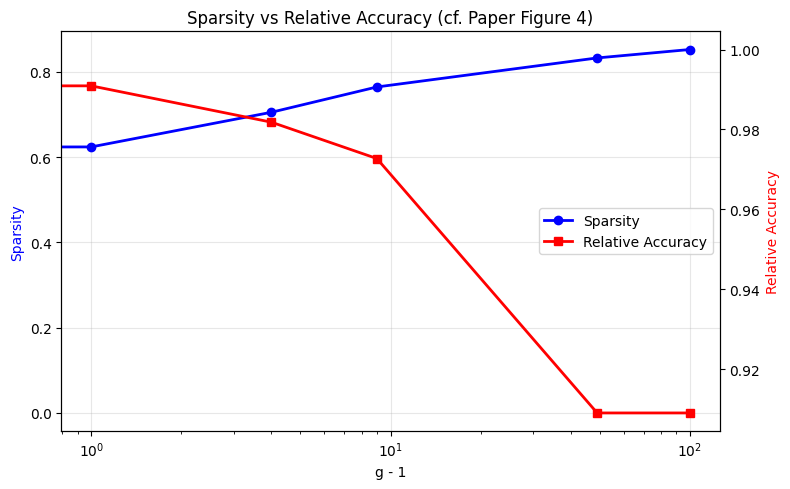

Saved: results/sparsity_vs_accuracy_tradeoff.png


In [9]:
sparsity_vals, rel_acc_vals, gamma_minus_1 = [], [], []
for g in gammas:
    a_acc, a_sv, _, _ = aux_results[g]
    sparsity_vals.append(1.0 - a_sv / T)
    rel_acc_vals.append(a_acc / nc_acc if nc_acc > 0 else 0)
    gamma_minus_1.append(g - 1)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
l1, = ax1.plot(gamma_minus_1, sparsity_vals, 'b-o', linewidth=2, label='Sparsity')
l2, = ax2.plot(gamma_minus_1, rel_acc_vals, 'r-s', linewidth=2, label='Relative Accuracy')
ax1.set_xlabel('g - 1')
ax1.set_ylabel('Sparsity', color='blue')
ax2.set_ylabel('Relative Accuracy', color='red')
ax1.set_xscale('log')
ax1.set_title('Sparsity vs Relative Accuracy (cf. Paper Figure 4)')
ax1.legend(handles=[l1, l2], loc='center right')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/sparsity_vs_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/sparsity_vs_accuracy_tradeoff.png')

This plot mirrors Figure 4 of the paper, showing the sparsity (fraction of training examples *not* used as support vectors) and relative accuracy (compared to NC) as $\gamma$ increases. Consistent with the paper, there is a range of $\gamma$ values that produce high sparsity without significant accuracy loss.